In [2]:
import pandas as pd

In [18]:
car = pd.read_csv('quikr_car.csv')
car.head(6)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel


In [22]:
car.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [24]:
print(df.columns)

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')


In [26]:
car['year'].unique()
car['Price'].unique()
car['kms_driven'].unique()
car['fuel_type'].unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [28]:
backup=car.copy()

In [30]:
car['year'].str.isnumeric()
car=car[car['year'].str.isnumeric()]

In [32]:
car['year'].astype(int)
car['year']=car['year'].astype(int)

In [34]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


In [36]:
car=car[car['Price']!='Ask For Price']
car['Price']=car['Price'].str.replace(",","").astype(int)

In [38]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


In [42]:
car['kms_driven']
car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')

In [44]:
car=car[car['kms_driven'].str.isnumeric()]
car['kms_driven']=car['kms_driven'].astype(int)

In [46]:
car.info()
car=car[~car['fuel_type'].isna()]

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [50]:
car.shape

(816, 6)

In [52]:
car['name'].str.split().str.slice(0,3)

0         [Hyundai, Santro, Xing]
1         [Mahindra, Jeep, CL550]
3           [Hyundai, Grand, i10]
4      [Ford, EcoSport, Titanium]
6                    [Ford, Figo]
                  ...            
883        [Maruti, Suzuki, Ritz]
885            [Tata, Indica, V2]
886      [Toyota, Corolla, Altis]
888              [Tata, Zest, XM]
889        [Mahindra, Quanto, C8]
Name: name, Length: 816, dtype: object

In [54]:
car['name'] =car['name'].str.split().str.slice(0,3).str.join(' ')

In [56]:
car=car.reset_index(drop=True)

In [58]:
car.info()
car.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


In [60]:
car=car[car['Price']<6e6].reset_index(drop=True)

In [62]:
car.to_csv('Cleaned_Car_data.csv')

In [64]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=34)

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [70]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

In [74]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),remainder='passthrough')

In [78]:
lr=LinearRegression()
lr

LinearRegression()

In [82]:
pipe=make_pipeline(column_trans,lr)
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [84]:
pipe.fit(X_train,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [90]:
y_pred=pipe.predict(X_test)
y_pred

array([ 119060.15957045,  432775.49247077,  550178.14631712,
        279690.28434318,  320855.58256321,  220294.72623338,
         80830.87649304,  156881.20021304,  470700.66806538,
        316977.30193824,  269333.00009079,  459495.45337989,
        750774.60029436,  729468.05041227,  459392.17222565,
        493821.37701415,  264160.15260075,   96142.87683981,
        435722.69504766,   83700.73192053, 2176850.94089223,
        563583.61174487,  120513.93962482,  428190.81137034,
        161233.45441528,  432363.01819096,  258243.911682  ,
        199830.46823777,  313160.13672937,  402315.96864782,
        574948.85146   ,  429964.43556321,  424523.01803336,
        142636.09215309,  514182.96371084,  604402.02306224,
        737831.64584544,  152886.30123777,  200177.47103906,
       1056830.0274897 ,  341708.81091993,  151943.59566107,
         77591.43072666,  359968.07613058,   95188.51656905,
        477448.58262321,  677706.12790413,  472296.74504285,
        208530.61591654,

In [88]:
r2_score(y_test,y_pred)

0.5622367572299051

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Top 10 Car Companies')

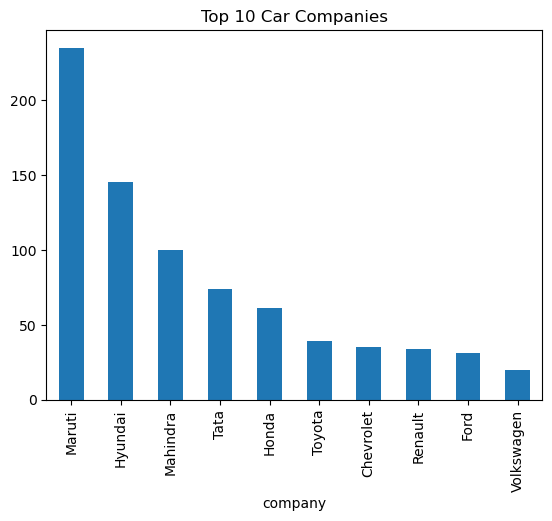

In [103]:
df['company'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Car Companies")

Text(0.5, 1.0, 'Fuel Type Distribution')

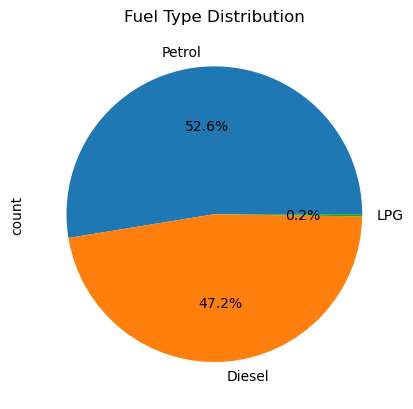

In [105]:
df['fuel_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Fuel Type Distribution")

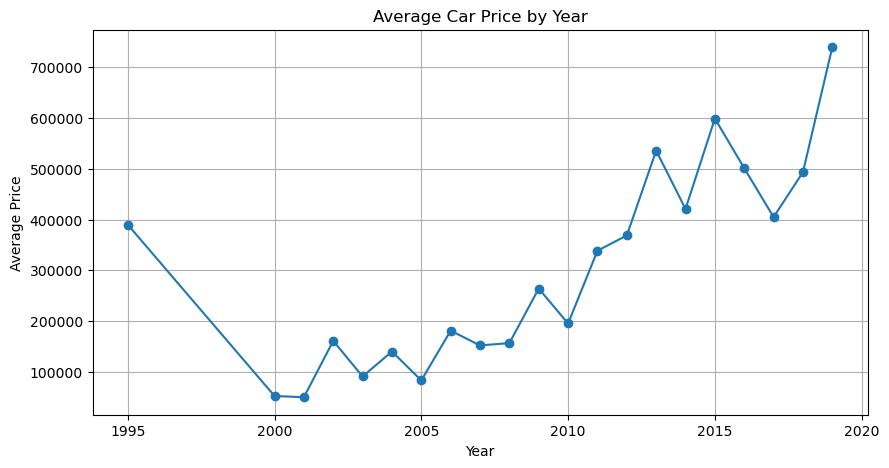

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

avg_price = car.groupby('year')['Price'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_price.index, avg_price.values, marker='o')
plt.title("Average Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

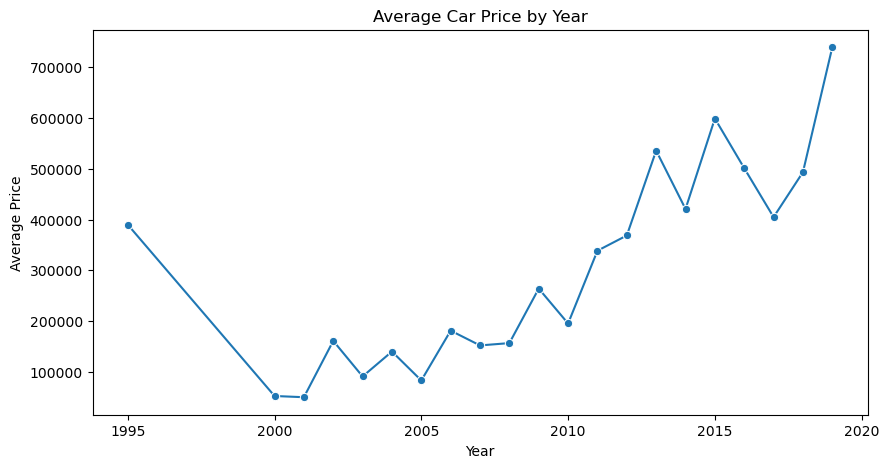

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_price = car.groupby('year', as_index=False)['Price'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(data=avg_price, x='year', y='Price', marker='o')
plt.title("Average Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

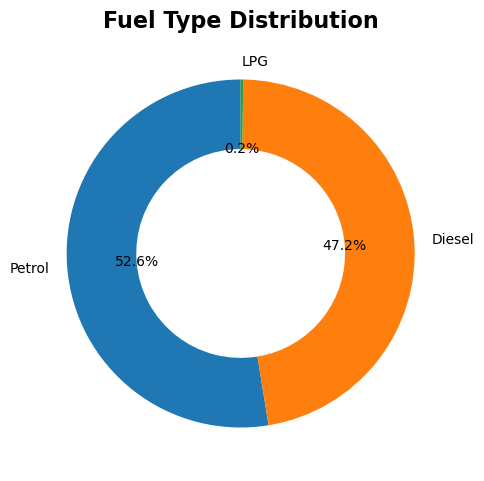

In [119]:
import matplotlib.pyplot as plt

fuel_counts = df['fuel_type'].value_counts()

plt.figure(figsize=(5,6))

plt.pie(
    fuel_counts,
    labels=fuel_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.title("Fuel Type Distribution", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

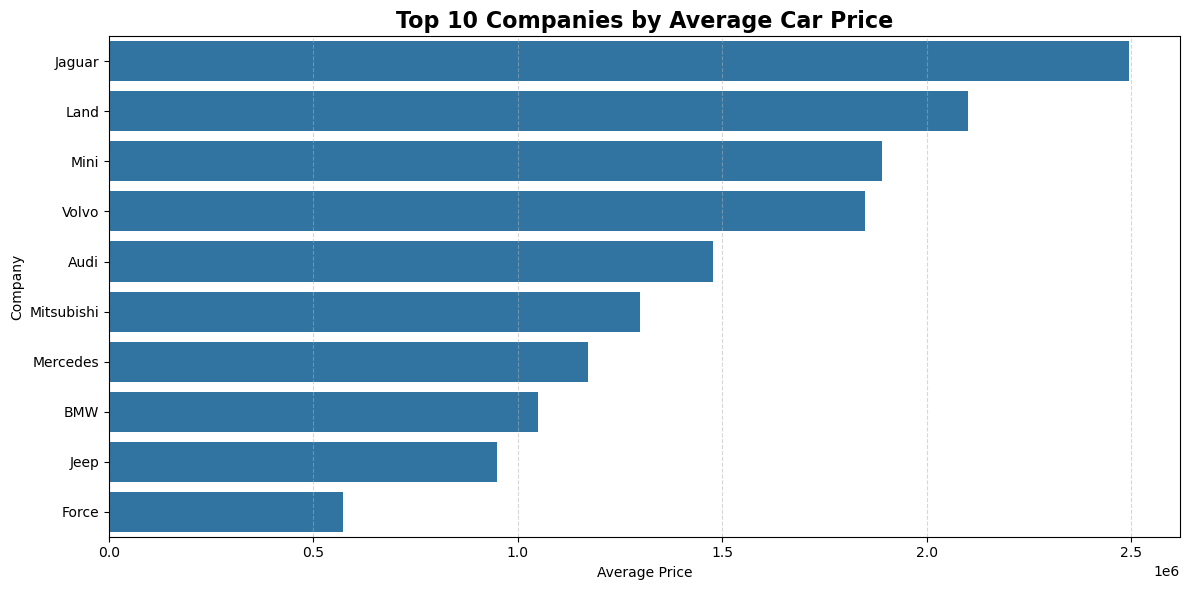

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

top_companies = (
    car.groupby('company')['Price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

plt.title(
    "Top 10 Companies by Average Car Price",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Price")
plt.ylabel("Company")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()